# ORIE 5256 Team Exercises: Advances in Financial Machine Learning

Each team solves three of the five exercises below (2.1, 3.1, 7.2, 13.2, 14.2).

**Dependencies:** 3.1, 13.2 and 14.2 start from the dollar bars built in 2.1, so 2.1 should be one of the three. 7.2 uses the (X, y) dataset produced in 3.1, so 7.2 only makes sense together with 3.1.

**Submission:** one notebook per team. All reasoning and explanations go in code comments.

**Data:** E-mini S&P 500 (ES) futures tick data, 1997-2015 (`ES-csv.zip`, 1.9 GB zipped, ~34 GB unzipped). It will not fit in memory, so document the out-of-core approach used.

In [9]:
# Setup and data-handling approach
#
# PROBLEM: ES.csv is 34 GB unzipped (1.9 GB zipped); it cannot be loaded into RAM.
# APPROACH: stream the CSV once out of the zip in fixed-size chunks and write each chunk
# to a year-partitioned, zstd-compressed Parquet dataset. Every later cell (bars, CUSUM,
# O-U fit, ...) reads Parquet, never the CSV.
#   - Streaming from the zip member avoids writing 34 GB of raw CSV to disk, and the
#     chunk size bounds peak RAM no matter how large the file is. We pipe `unzip -p`
#     because Python's zipfile cannot decompress this archive (unsupported method,
#     typical for >4 GB zips); the system unzip can.
#   - Parquet is columnar and typed: ~5x smaller than CSV, no re-parsing of text on every
#     read, and we can load only the columns we need.
#   - Partitioning by year lets later cells read one year at a time (or a slice for
#     development) instead of the whole history.
#   - data/ is gitignored, so none of this ever enters version control.
from __future__ import annotations  # lets `int | None` hints work on Python 3.9 kernels

import shutil
import subprocess
from pathlib import Path

import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

# Configuration over hardcoding: one place to change paths and sizes.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ZIP_PATH = REPO_ROOT / "ES-csv.zip"
CSV_NAME = "ES.csv"
PARQUET_DIR = REPO_ROOT / "data" / "interim" / "ticks_parquet"
CHUNK_ROWS = 5_000_000  # ~250 MB per chunk in pandas; small enough for any laptop
MAX_ROWS = None  # set e.g. 2_000_000 to smoke-test on a slice (writes to a separate dir)

# The file has no header. Raw time is HHMMSSmmm (e.g. 000649000 = 00:06:49.000) and is
# read as an integer, so we avoid slow string parsing on 34 GB of text.
COLUMNS = ["contract", "date", "time", "price", "size", "type"]
DTYPES = {"contract": "string", "date": "int32", "time": "int32",
          "price": "float64", "size": "int32", "type": "string"}
# float64 price is exact here: ES ticks are multiples of 0.25 (a power of two).


def to_timestamp(date: pd.Series, time: pd.Series) -> pd.Series:
    """Combine YYYYMMDD and HHMMSSmmm ints into one datetime64[ms] column."""
    day = pd.to_datetime(date.astype("int64").astype("string"), format="%Y%m%d")
    t = time.astype("int64")
    offset_ms = ((t // 10_000_000) * 3_600_000 + (t // 100_000 % 100) * 60_000
                 + (t // 1_000 % 100) * 1_000 + t % 1_000)
    return (day + pd.to_timedelta(offset_ms, unit="ms")).astype("datetime64[ms]")


def convert_csv_to_parquet(out_dir: Path, max_rows: int | None) -> None:
    """Stream ES.csv from the zip into year-partitioned Parquet, validating each chunk."""
    marker = out_dir / "_SUCCESS"
    # Idempotence: a finished conversion is never redone. A directory without the
    # marker is a crashed run, so it is wiped (partial parts would duplicate rows).
    if marker.exists():
        print(f"Parquet already built at {out_dir}; skipping conversion.")
        return
    if out_dir.exists():
        shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True)

    n_rows, ts_min, ts_max = 0, None, None
    proc = subprocess.Popen(["unzip", "-p", str(ZIP_PATH), CSV_NAME], stdout=subprocess.PIPE)
    try:
        reader = pd.read_csv(proc.stdout, header=None, names=COLUMNS, dtype=DTYPES,
                             chunksize=CHUNK_ROWS, nrows=max_rows)
        for i, chunk in enumerate(reader):
            # Fail fast: a bad parse should stop the job now, not after hours of bars.
            assert not chunk.isna().any().any(), f"nulls in chunk {i}"
            chunk["timestamp"] = to_timestamp(chunk.pop("date"), chunk.pop("time"))
            chunk["year"] = chunk["timestamp"].dt.year.astype("int16")
            for year, part in chunk.groupby("year"):  # a chunk can straddle New Year
                year_dir = out_dir / f"year={year}"
                year_dir.mkdir(exist_ok=True)
                part = part.drop(columns="year")
                pq.write_table(pa.Table.from_pandas(part, preserve_index=False),
                               year_dir / f"part-{i:05d}.parquet", compression="zstd")
            n_rows += len(chunk)
            lo, hi = chunk["timestamp"].min(), chunk["timestamp"].max()
            ts_min = lo if ts_min is None else min(ts_min, lo)
            ts_max = hi if ts_max is None else max(ts_max, hi)
            print(f"chunk {i}: {n_rows:,} rows so far, up to {hi}", flush=True)
    finally:
        proc.stdout.close()  # unzip gets SIGPIPE if we stop early (MAX_ROWS)
        proc.wait()
    if proc.returncode not in (0, -13):  # -13 = SIGPIPE from early stop
        raise RuntimeError(f"unzip failed with code {proc.returncode}")
    marker.write_text(f"rows={n_rows}\nmin={ts_min}\nmax={ts_max}\n")  # last: marks success
    print(f"Done: {n_rows:,} rows, {ts_min} -> {ts_max}")


# Smoke-test runs go to their own directory so they never masquerade as the full dataset.
_out_dir = PARQUET_DIR if MAX_ROWS is None else PARQUET_DIR.with_name("ticks_parquet_sample")
convert_csv_to_parquet(_out_dir, MAX_ROWS)

# DOWNSTREAM USE: read one year (or a few columns) at a time, e.g.
#   pq.read_table(PARQUET_DIR, filters=[("year", "==", 2008)], columns=["timestamp", "price", "size"])
# Exercise 2.1 builds tick/volume/dollar bars year by year from this dataset.

Parquet already built at /Users/MaximilianYap/ORIE 5256 Lopez de Prado Financial Machine Learning/data/interim/ticks_parquet; skipping conversion.


## Exercise 2.1

On a series of E-mini S&P 500 futures tick data:

- (a) Form tick, volume, and dollar bars. Use the ETF trick to deal with the roll.
- (b) Count the number of bars produced by tick, volume, and dollar bars on a weekly basis. Plot a time series of that bar count. What bar type produces the most stable weekly count? Why?
- (c) Compute the serial correlation of returns for the three bar types. What bar method has the lowest serial correlation?
- (d) Partition the bar series into monthly subsets. Compute the variance of returns for every subset of every bar type. Compute the variance of those variances. What method exhibits the smallest variance of variances?
- (e) Apply the Jarque-Bera normality test on returns from the three bar types. What method achieves the lowest test statistic?

### Context for Exercise 2.1: the ETF trick (AFML §2.4.1)

**Problem.** Futures expire and must be rolled, and spreads or baskets have weights that change over time. Modeling the raw series gives trouble: a roll or a reweighting moves the price level without any PnL, a spread can turn negative, and the constituents do not all trade at the same instants. Using the ETF trick, any of these is converted into one series that behaves like a total-return ETF, so downstream code only ever has to handle a single, non-expiring **cash product**.

**Idea.** Track the value $K_t$ of \$1 invested in the basket ($K_0 = 1$). Changes in $K_t$ are the PnL of the strategy, $K_t$ stays strictly positive, and rolls/rebalances are absorbed by re-investing at the new prices.

**Inputs per bar $t = 1,\dots,T$ and instrument $i = 1,\dots,I$:**

- $o_{i,t}$: raw open price
- $p_{i,t}$: raw close price
- $\varphi_{i,t}$: USD value of one point (includes the FX rate)
- $v_{i,t}$: volume
- $d_{i,t}$: carry, dividend or coupon paid (can also charge margin or funding costs)
- All instruments must be tradeable at $t-1$ and $t$.

**Construction.** Let $\omega_t$ be the allocation vector, rebalanced (or rolled) on the bars $B \subseteq \{1,\dots,T\}$, with $K_0 = 1$.

- Holdings (number of contracts) of instrument $i$:

$$
h_{i,t} =
\begin{cases}
\dfrac{\omega_{i,t}\,K_t}{o_{i,t+1}\,\varphi_{i,t}\,\sum_{j=1}^{I}|\omega_{j,t}|} & t \in B \\[2ex]
h_{i,t-1} & \text{otherwise}
\end{cases}
$$

  On $t \in B$ the book is reset to the new weights, de-levered by $\sum|\omega|$, and sized with $K_t$, so profits and losses are reinvested (this is what prevents negative values). The next open $o_{t+1}$ is used because the new contract's close $p_t$ may be unknown at a roll.

- Change in market value between $t-1$ and $t$:

$$
\delta_{i,t} =
\begin{cases}
p_{i,t} - o_{i,t} & (t-1) \in B \\
\Delta p_{i,t} & \text{otherwise}
\end{cases}
$$

  On the bar right after a rebalance it is measured from the open (the fill price), otherwise close-to-close.

- Value of the \$1 investment:

$$
K_t = K_{t-1} + \sum_{i=1}^{I} h_{i,t-1}\,\varphi_{i,t}\,\bigl(\delta_{i,t} + d_{i,t}\bigr)
$$

  Carry $d_{i,t}$ is embedded in $K_t$, so the strategy does not need to know about it.

**Extra quantities the strategy needs for every bar** (transaction cost per \$1 traded is $\tau_i$, e.g. $10^{-4}$):

1. *Rebalance cost* $c_t = \sum_i \bigl(|h_{i,t-1}|\,p_{i,t} + |h_{i,t}|\,o_{i,t+1}\bigr)\varphi_{i,t}\tau_i$ for $t \in B$. It is kept out of $K_t$ (otherwise shorting the spread would show fictitious profit at a rebalance) and treated as a negative dividend.
2. *Bid-ask cost* of one unit of the virtual ETF: $\tilde c_t = \sum_i |h_{i,t-1}|\,p_{i,t}\,\varphi_{i,t}\tau_i$.
3. *Volume* in basket units, set by the least active member: $v_t = \min_i \bigl\{ v_{i,t} / |h_{i,t-1}| \bigr\}$.

**Application to ES (this notebook).** A single outright future, so $I = 1$, $\omega = 1$, and $B$ is the set of roll ticks. Every tick is its own bar ($o = p = $ price), so $K_t$ compounds with the price change inside a contract and is unchanged on the first tick of the new contract; the old-vs-new price gap is therefore not counted as PnL. The simplifications are $d = 0$ and $\tau = 0$, so $c_t$ and $\tilde c_t$ are not modeled.

In [10]:
# Exercise 2.1 (a): tick, volume and dollar bars (plus time bars) built on the ETF-trick series
#
# PIPELINE (one streaming pass over the Parquet part files, so RAM stays bounded):
#   ticks -> ETF-trick value K of $1 held in the front contract -> bar builders
#   - Contract roll: each tick carries its contract (ESH08, ESM08, ...). Only the front
#     contract trades at any time, so a roll is a change of the `contract` field. On a roll
#     tick the $1 is moved into the new contract (K unchanged), so the old-vs-new price gap
#     never shows up as PnL. Within a contract K compounds with the price change.
#     This is the book's ETF trick with I=1, omega=1, B=roll ticks, d=0, tau=0 (no carry,
#     no transaction costs); every tick is treated as its own bar (o = p = price).
#   - Bar OHLC are taken on K (continuous, positive, roll-free). Volume (contracts) and
#     dollar value (raw price * size * POINT_VALUE) are real traded quantities, so they stay
#     on the raw price. Sampling thresholds are therefore in contracts / real dollars.
#   - DATA GAP: `size` is 0 on every tick before July 2003 (no volume was recorded). Ticks with
#     zero quantity cannot advance a volume or dollar bar, so they are skipped by those
#     builders: volume and dollar bars start 2003-07-01, tick bars start in 1997.
#   - A bar closes on the tick that makes its running total reach the threshold, and that
#     tick belongs to the bar it closes. Bars straddling two files are carried over.
#   - TIME BARS are added PURELY FOR COMPARISON. The exercise asks for tick, volume and dollar
#     bars; time bars are the naive baseline (sample on the clock, not on market activity)
#     that the three information-driven bars are compared against in 2.1 (b) onwards.
#     They are built on the same K series by the same streaming pass.
from typing import Callable, Dict, List

import numpy as np

# Configuration over hardcoding
BARS_DIR = REPO_ROOT / "data" / "processed" / "bars"
POINT_VALUE = 50.0  # USD per index point of one ES contract
TARGET_BARS_PER_DAY = 50  # sets each threshold: total quantity / (target * days with data)
MAX_FILES = None  # set e.g. 10 to smoke-test on the first files (writes to a separate dir)
BAR_TYPES = ["tick", "volume", "dollar", "time"]  # "time" is for comparison only
TIME_BAR_MS = 30 * 60 * 1000  # 30-minute clock bars: ~46/day over a ~23h session, close to TARGET_BARS_PER_DAY

# What each bar type counts per tick; ticks with quantity <= 0 are skipped.
QUANTITY: Dict[str, Callable[[pd.DataFrame], np.ndarray]] = {
    "tick": lambda t: np.ones(len(t)),
    "volume": lambda t: t["size"].to_numpy(dtype="float64"),
    "dollar": lambda t: t["dollar"].to_numpy(dtype="float64"),
}

# How to merge several bars (or partial bars) that share a bar_id.
BAR_AGG = {"open": "first", "high": "max", "low": "min", "close": "last",
           "volume": "sum", "dollar": "sum", "ticks": "sum", "start": "first", "end": "last"}


def tick_files(root: Path) -> List[Path]:
    """Part files in time order: chunk number first; within one chunk, earlier year first."""
    files = sorted(root.glob("year=*/part-*.parquet"), key=lambda p: (p.name, p.parent.name))
    return files if MAX_FILES is None else files[:MAX_FILES]


def read_ticks(path: Path) -> pd.DataFrame:
    ticks = pq.read_table(path, columns=["timestamp", "contract", "price", "size"]).to_pandas()
    assert ticks["timestamp"].is_monotonic_increasing, f"{path} is not time-ordered"
    assert (ticks["price"] > 0).all(), f"non-positive price in {path}"
    ticks["dollar"] = ticks["price"] * ticks["size"] * POINT_VALUE
    return ticks


class EtfTrickSeries:
    """Streaming value K of $1 invested in the front ES contract, rolled at contract changes."""

    def __init__(self) -> None:
        self._k = 1.0  # K_0 = 1
        self._last_price = None
        self._last_contract = None
        self._retired: set = set()

    def transform(self, ticks: pd.DataFrame) -> np.ndarray:
        price = ticks["price"].to_numpy()
        contract = ticks["contract"].to_numpy(dtype=object)
        prev_price = np.concatenate(([price[0] if self._last_price is None else self._last_price], price[:-1]))
        prev_contract = np.concatenate(([contract[0] if self._last_contract is None else self._last_contract], contract[:-1]))
        rolled = contract != prev_contract
        # Fail fast: a contract that was left must never trade again, or K would double count.
        for old, new in zip(prev_contract[rolled], contract[rolled]):
            self._retired.add(old)
            assert new not in self._retired, f"contract {new} traded again after its roll"
        growth = np.where(rolled, 1.0, price / prev_price)  # on a roll the $1 is re-bought at p
        k = self._k * np.cumprod(growth)
        self._k, self._last_price, self._last_contract = k[-1], price[-1], contract[-1]
        return k


def aggregate_ticks(bar_id, k, size, dollar, ts) -> pd.DataFrame:
    """Collapse ticks with a non-decreasing bar_id into one row per bar."""
    first = np.flatnonzero(np.r_[True, bar_id[1:] != bar_id[:-1]])
    last = np.r_[first[1:], len(bar_id)] - 1
    return pd.DataFrame({
        "open": k[first], "high": np.maximum.reduceat(k, first), "low": np.minimum.reduceat(k, first),
        "close": k[last], "volume": np.add.reduceat(size, first), "dollar": np.add.reduceat(dollar, first),
        "ticks": last - first + 1, "start": ts[first], "end": ts[last],
    }, index=pd.Index(bar_id[first], name="bar_id"))


class BarBuilder:
    """Streaming bar sampler: closes a bar each time the running quantity crosses a multiple of threshold."""

    def __init__(self, quantity: Callable[[pd.DataFrame], np.ndarray], threshold: float) -> None:
        assert threshold > 0, "threshold must be positive"
        self._quantity, self._threshold = quantity, threshold
        self._running = 0.0  # quantity accumulated before the current file
        self._pending = None  # last, still open, bar
        self._done: List[pd.DataFrame] = []

    def _assign(self, ticks: pd.DataFrame):
        """Keep the ticks that count and give each the id of the bar it belongs to."""
        q = self._quantity(ticks)
        live = q > 0
        ticks, q = ticks[live], q[live]
        # Bar of a tick = how many thresholds were already filled before it (exclusive cumsum),
        # so the tick that crosses the threshold stays in, and closes, its own bar.
        bar_id = ((self._running + np.cumsum(q) - q) // self._threshold).astype(np.int64)
        self._running += q.sum()
        return ticks, bar_id

    def update(self, ticks: pd.DataFrame) -> None:
        ticks, bar_id = self._assign(ticks)
        if len(ticks) == 0:
            return
        bars = aggregate_ticks(bar_id, ticks["k"].to_numpy(), ticks["size"].to_numpy(dtype="int64"),
                               ticks["dollar"].to_numpy(), ticks["timestamp"].to_numpy())
        parts = bars if self._pending is None else pd.concat([self._pending, bars])
        merged = parts.groupby(level="bar_id", sort=False).agg(BAR_AGG)  # joins a bar split across files
        self._done.append(merged.iloc[:-1])
        self._pending = merged.iloc[-1:]

    def bars(self) -> pd.DataFrame:
        """Completed bars indexed by close time; the final unfinished bar is dropped."""
        return pd.concat(self._done).reset_index(drop=True).set_index("end")


class TimeBarBuilder(BarBuilder):
    """Comparison baseline: a new bar every `interval_ms` of clock time, whatever the activity."""

    def __init__(self, interval_ms: int) -> None:
        super().__init__(QUANTITY["tick"], interval_ms)  # quantity is unused, only the threshold

    def _assign(self, ticks: pd.DataFrame):
        ms = ticks["timestamp"].to_numpy().astype("datetime64[ms]").astype(np.int64)
        return ticks, ms // self._threshold


def calibrate_thresholds(files: List[Path]) -> Dict[str, float]:
    """Threshold giving ~TARGET_BARS_PER_DAY bars/day on average, over days where the quantity exists."""
    total = dict.fromkeys(QUANTITY, 0.0)
    days = {name: set() for name in QUANTITY}
    for path in files:
        ticks = read_ticks(path)
        for name in QUANTITY:
            q = QUANTITY[name](ticks)
            live = q > 0
            total[name] += q[live].sum()
            days[name].update(ticks["timestamp"][live].dt.normalize().unique())
    return {name: total[name] / (TARGET_BARS_PER_DAY * len(days[name])) for name in QUANTITY}


def build_bars(files: List[Path], thresholds: Dict[str, float]) -> Dict[str, pd.DataFrame]:
    etf = EtfTrickSeries()
    builders = {name: BarBuilder(QUANTITY[name], thresholds[name]) for name in QUANTITY}
    builders["time"] = TimeBarBuilder(TIME_BAR_MS)
    for i, path in enumerate(files):
        ticks = read_ticks(path)
        ticks["k"] = etf.transform(ticks)
        for builder in builders.values():
            builder.update(ticks)
        print(f"file {i + 1}/{len(files)}: {path.parent.name}/{path.name}", flush=True)
    return {name: builder.bars() for name, builder in builders.items()}

In [11]:
# Exercise 2.1 (a): build (or load) the bar series (time bars for comparison only)
# Bars are tiny next to the ticks (~50/day), so they are kept in memory and cached as Parquet.
# Thresholds come from one extra pass over the data so each type averages ~TARGET_BARS_PER_DAY.
_bars_dir = BARS_DIR if MAX_FILES is None else BARS_DIR.with_name("bars_sample")
_bar_paths = {name: _bars_dir / f"{name}_bars.parquet" for name in BAR_TYPES}

if all(p.exists() for p in _bar_paths.values()):
    bars = {name: pd.read_parquet(p) for name, p in _bar_paths.items()}
    print(f"Loaded cached bars from {_bars_dir}")
else:
    _files = tick_files(PARQUET_DIR)
    thresholds = calibrate_thresholds(_files)
    print("thresholds:", thresholds)
    bars = build_bars(_files, thresholds)
    _bars_dir.mkdir(parents=True, exist_ok=True)
    for name, path in _bar_paths.items():
        bars[name].to_parquet(path, compression="zstd")

for name, df in bars.items():
    print(f"{name:>6}: {len(df):>9,} bars, {df.index.min()} -> {df.index.max()}")

Loaded cached bars from /Users/MaximilianYap/ORIE 5256 Lopez de Prado Financial Machine Learning/data/processed/bars
  tick:   263,149 bars, 1997-09-11 08:56:02 -> 2015-10-13 15:08:48.245000
volume:   190,299 bars, 2003-07-01 08:31:27 -> 2015-10-13 15:12:45.923000
dollar:   190,299 bars, 2003-07-01 08:34:32 -> 2015-10-13 15:14:31.748000
  time:   190,908 bars, 1997-09-10 00:13:18 -> 2015-10-13 15:14:59.961000


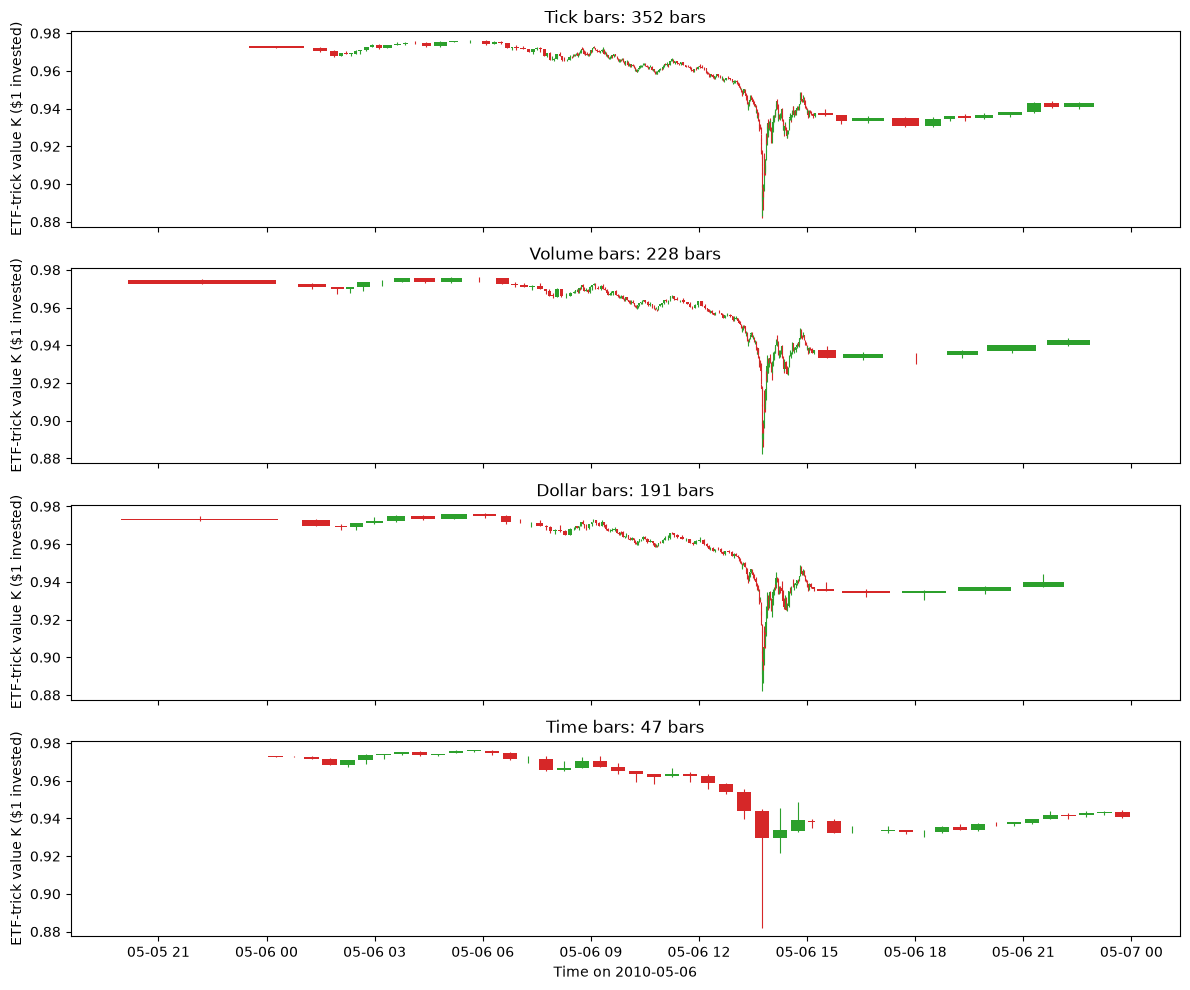

In [12]:
# Exercise 2.1 (a): illustration of the three bar types on one session
# 2010-05-06 (the "flash crash") is a good test: bars are sampled densely while trading is
# heavy and sparsely in the quiet overnight hours, and K stays continuous (no roll gap).
# Candle width spans the time the bar took to fill; green = close >= open.
import matplotlib.pyplot as plt

ILLUSTRATION_DAY = "2010-05-06"


def draw_candles(ax, df: pd.DataFrame, title: str) -> None:
    """OHLC candles drawn over each bar's span [start, end]."""
    for row in df.itertuples():
        up = row.close >= row.open
        colour = "tab:green" if up else "tab:red"
        mid = row.start + (row.Index - row.start) / 2
        ax.vlines(mid, row.low, row.high, color=colour, linewidth=0.8)
        ax.bar(mid, abs(row.close - row.open) or 1e-6, bottom=min(row.open, row.close),
               width=(row.Index - row.start) * 0.8 or pd.Timedelta(seconds=1), color=colour)
    ax.set_title(f"{title}: {len(df)} bars")
    ax.set_ylabel("ETF-trick value K ($1 invested)")


fig, axes = plt.subplots(len(BAR_TYPES), 1, figsize=(12, 10), sharex=True)
for ax, name in zip(axes, BAR_TYPES):
    day = bars[name].loc[ILLUSTRATION_DAY]
    draw_candles(ax, day, f"{name.capitalize()} bars")
axes[-1].set_xlabel(f"Time on {ILLUSTRATION_DAY}")
fig.tight_layout()
plt.show()

### Exercise 2.1b

Answer to 2.1B: Time bars are by far the most stable, but only because the clock fixes their count. Among the activity-driven bars, volume and dollar bars are about 4x more stable than tick bars. This possibly may be due to tick counts jumping to a much higher level after 2008, which might be contributing to less stable bars. The rise in ticks possibly arises due to a sustained rise in trading activity as markets became more electronified.

640 weeks, 2003-07-13 -> 2015-10-11
          mean  variance     std  std / mean
tick    389.52  80461.00  283.66        0.73
volume  297.09  20882.03  144.51        0.49
dollar  297.05  21678.46  147.24        0.50
time    228.25    223.30   14.94        0.07


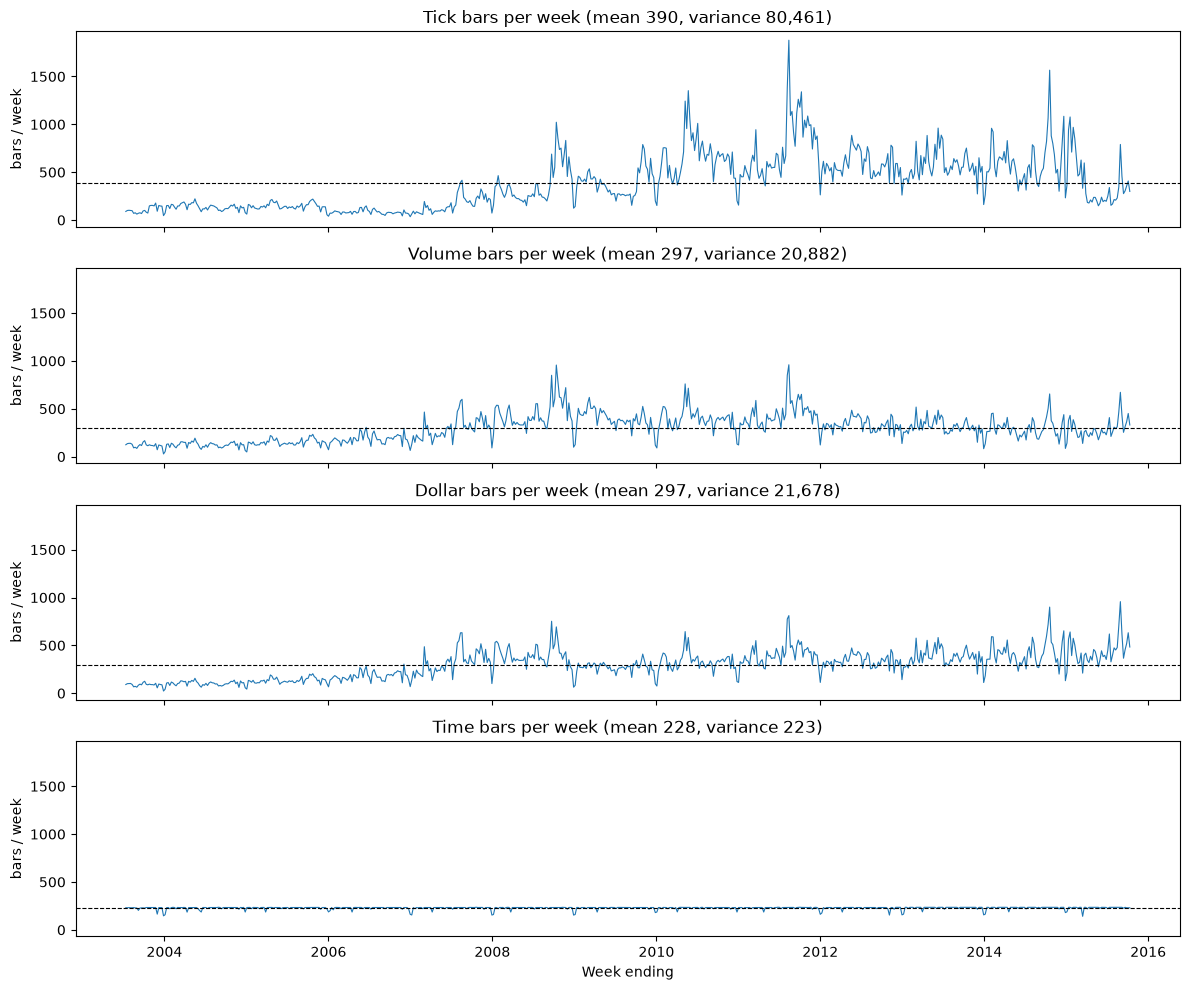

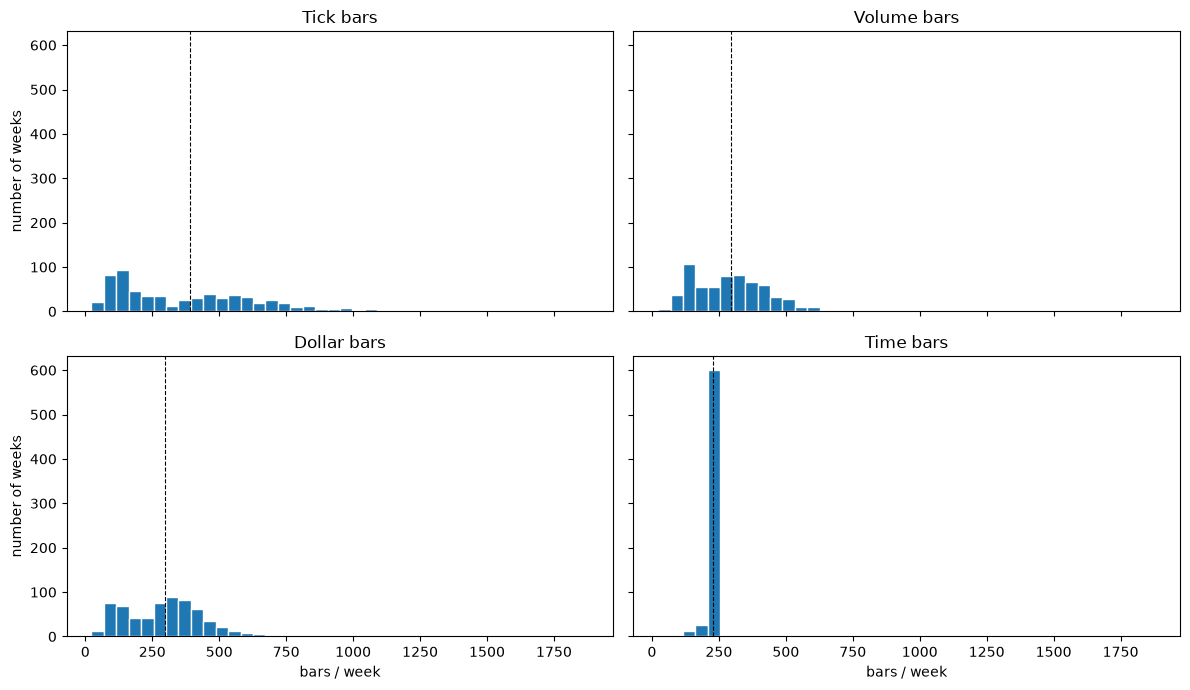

In [13]:
# Exercise 2.1 (b): weekly bar counts for tick, volume, dollar (and time, for comparison) bars
# All four series are compared over the same weeks: volume and dollar bars only exist from
# 2003-07-01 (size is 0 before that), so earlier weeks are dropped, and so are the first and
# last weeks of the common window because they are partial.
weekly = pd.DataFrame({name: df.resample("W").size() for name, df in bars.items()})
weekly = weekly.dropna().iloc[1:-1].astype(int)

stats = pd.DataFrame({"mean": weekly.mean(), "variance": weekly.var(),
                      "std": weekly.std(), "std / mean": weekly.std() / weekly.mean()})
print(f"{len(weekly)} weeks, {weekly.index.min().date()} -> {weekly.index.max().date()}")
print(stats.round(2))

# Time series of weekly counts (shared axes so the scatter around the level is comparable).
fig, axes = plt.subplots(len(BAR_TYPES), 1, figsize=(12, 10), sharex=True, sharey=True)
for ax, name in zip(axes, BAR_TYPES):
    ax.plot(weekly.index, weekly[name], linewidth=0.8)
    ax.axhline(weekly[name].mean(), color="k", linestyle="--", linewidth=0.8)
    ax.set_title(f"{name.capitalize()} bars per week (mean {weekly[name].mean():,.0f}, "
                 f"variance {weekly[name].var():,.0f})")
    ax.set_ylabel("bars / week")
axes[-1].set_xlabel("Week ending")
fig.tight_layout()
plt.show()

# Distribution of weekly counts (same bins and x-range for every type).
edges = np.linspace(weekly.min().min(), weekly.max().max(), 41)
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
for ax, name in zip(axes.ravel(), BAR_TYPES):
    ax.hist(weekly[name], bins=edges, edgecolor="white")
    ax.axvline(weekly[name].mean(), color="k", linestyle="--", linewidth=0.8)
    ax.set_title(f"{name.capitalize()} bars")
for ax in axes[-1]:
    ax.set_xlabel("bars / week")
for ax in axes[:, 0]:
    ax.set_ylabel("number of weeks")
fig.tight_layout()
plt.show()

# READING THE RESULT (full 2003-2015 run): time bars have by far the most stable weekly count
# (variance ~223 vs ~21,000 for volume/dollar and ~80,000 for tick), but only because the clock
# fixes it by construction (a dip only in holiday weeks); that is why they are comparison only.
# Among the activity-driven bars, volume and dollar bars are about 4x more stable than tick bars.
# Thresholds are fixed, so counts still follow market activity (volume and dollar bars climb
# from 2007-2008), and tick counts swing the most, with a far higher level after 2008.


### Exercise 2.1c

Answer to 2.1C: Answering this question seems to depend somewhat on how far back we look for auto correlation. Tick bars have the lowest magnitude (-0.0097, vs -0.0131 volume, -0.0130 dollar), while time bars are the largest

serial correlation of returns by lag:
        tick  volume  dollar    time
lag                                 
1    -0.0097 -0.0131 -0.0130  0.0085
2    -0.0103 -0.0070 -0.0045 -0.0250
3    -0.0015 -0.0041 -0.0027  0.0018
4     0.0019 -0.0045  0.0009 -0.0079
5     0.0070 -0.0027 -0.0079  0.0013
...      ...     ...     ...     ...
996  -0.0025 -0.0024 -0.0039  0.0040
997  -0.0023 -0.0044 -0.0005 -0.0072
998   0.0022 -0.0003  0.0018 -0.0001
999   0.0028  0.0026 -0.0013 -0.0050
1000 -0.0036  0.0023  0.0030 -0.0051

[1000 rows x 4 columns]

95% significance band (+/-): {'tick': 0.0039, 'volume': 0.0045, 'dollar': 0.0045, 'time': 0.0051}
lowest |lag-1 serial correlation| among tick/volume/dollar: tick

serial correlation summary over lags 1..1000:
        n_bars  sum rho^2  Ljung-Box Q  p-value  share of lags beyond band
tick    249422     0.0151    3776.1395      0.0                      0.316
volume  190298     0.0152    2893.3070      0.0                      0.256
dollar  190298     0

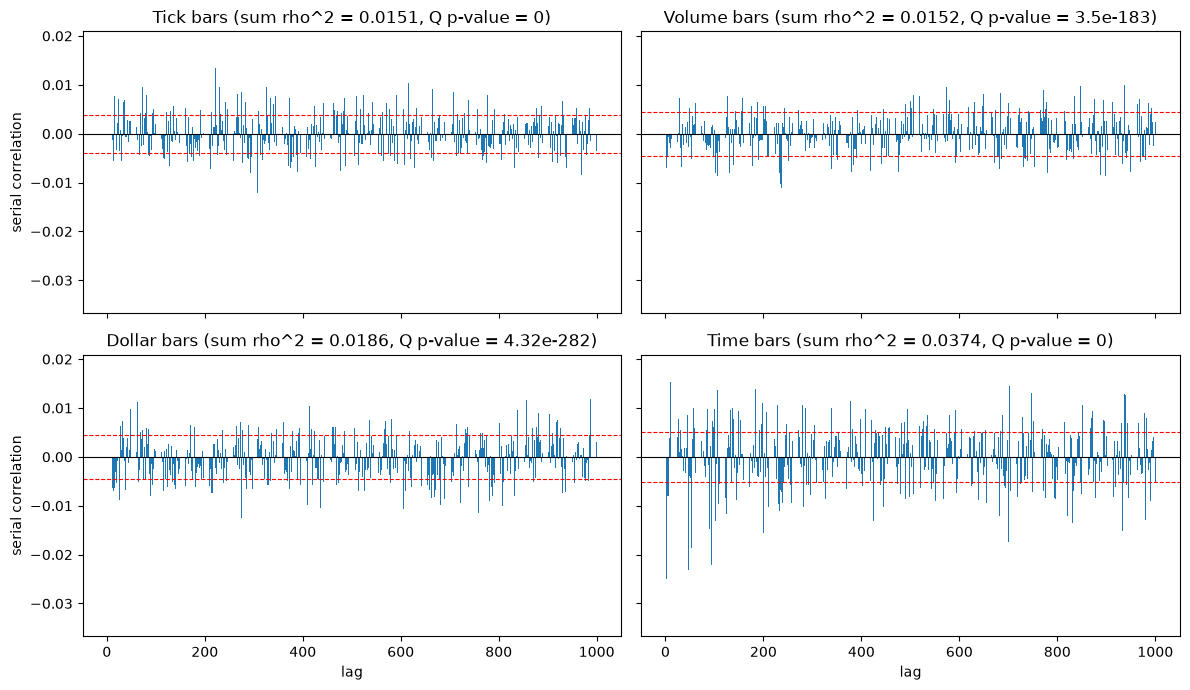

In [22]:
# Exercise 2.1 (c): serial correlation of bar returns
# Return = log change of the ETF-trick close from one bar to the next (roll-free, so a
# contract roll never shows up as a return). Computed over the window all types share
# (from 2003-07-01, when volume and dollar bars start), so the comparison is like for like.
# Under the null of no serial correlation, the sample autocorrelation has standard error
# ~1/sqrt(n), so |rho| > 1.96/sqrt(n) is significant at 5%. Time bars are comparison only.
from scipy.stats import chi2

_start = max(df.index.min() for df in bars.values())
returns = {name: np.log(df["close"]).diff().dropna().loc[_start:] for name, df in bars.items()}

MAX_LAG = 1000
lags = np.arange(1, MAX_LAG + 1)
acf = pd.DataFrame({name: [r.autocorr(lag) for lag in lags] for name, r in returns.items()},
                   index=pd.Index(lags, name="lag"))
n_bars = pd.Series({name: len(r) for name, r in returns.items()})
band = 1.96 / np.sqrt(n_bars)
print("serial correlation of returns by lag:")
print(acf.round(4))
print("\n95% significance band (+/-):", band.round(4).to_dict())
print("lowest |lag-1 serial correlation| among tick/volume/dollar:",
      acf.loc[1, ["tick", "volume", "dollar"]].abs().idxmin())

# SUMMARY STAT: amount of serial correlation over lags 1..MAX_LAG.
#   - sum rho^2: total squared autocorrelation. It does not depend on n, so it is comparable
#     across bar types with different bar counts (smaller = less serial correlation).
#   - Ljung-Box Q = n(n+2) * sum_k rho_k^2 / (n-k), ~ chi2(MAX_LAG) under no serial correlation;
#     the p-value tests the joint null. Q grows with n, so rank on sum rho^2, not on Q.
sum_rho2 = (acf ** 2).sum()
ljung_q = n_bars * (n_bars + 2) * acf.pow(2).div(n_bars.values - lags[:, None]).sum()
summary = pd.DataFrame({"n_bars": n_bars, "sum rho^2": sum_rho2, "Ljung-Box Q": ljung_q,
                        "p-value": chi2.sf(ljung_q, df=MAX_LAG),
                        "share of lags beyond band": (acf.abs() > band).mean()})
print(f"\nserial correlation summary over lags 1..{MAX_LAG}:")
print(summary.round(4))
print("lowest sum rho^2 among tick/volume/dollar:", sum_rho2[["tick", "volume", "dollar"]].idxmin())

# One subplot per bar type, shared y-axis so the magnitudes are comparable; dashed lines = 95% band.
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
for ax, name in zip(axes.ravel(), BAR_TYPES):
    ax.bar(lags, acf[name], width=0.8)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.axhline(band[name], color="r", linestyle="--", linewidth=0.8)
    ax.axhline(-band[name], color="r", linestyle="--", linewidth=0.8)
    ax.set_title(f"{name.capitalize()} bars (sum rho^2 = {sum_rho2[name]:.4f}, "
                 f"Q p-value = {summary.loc[name, 'p-value']:.3g})")
for ax in axes[-1]:
    ax.set_xlabel("lag")
for ax in axes[:, 0]:
    ax.set_ylabel("serial correlation")
fig.tight_layout()
plt.show()



### Exercise 2.1d

Answer to 2.1D: Tick bars exhibit the smallest variance of variances.

147 months, 2003-07 -> 2015-09
        months  mean monthly var  var of variances  std / mean
tick       147         1.948e-06         5.048e-12       1.153
volume     147         1.906e-06          5.11e-12       1.186
dollar     147         2.232e-06         1.109e-11       1.492
time       147         2.982e-06         3.985e-11       2.117
smallest variance of variances among tick/volume/dollar: tick
smallest std / mean among tick/volume/dollar: tick


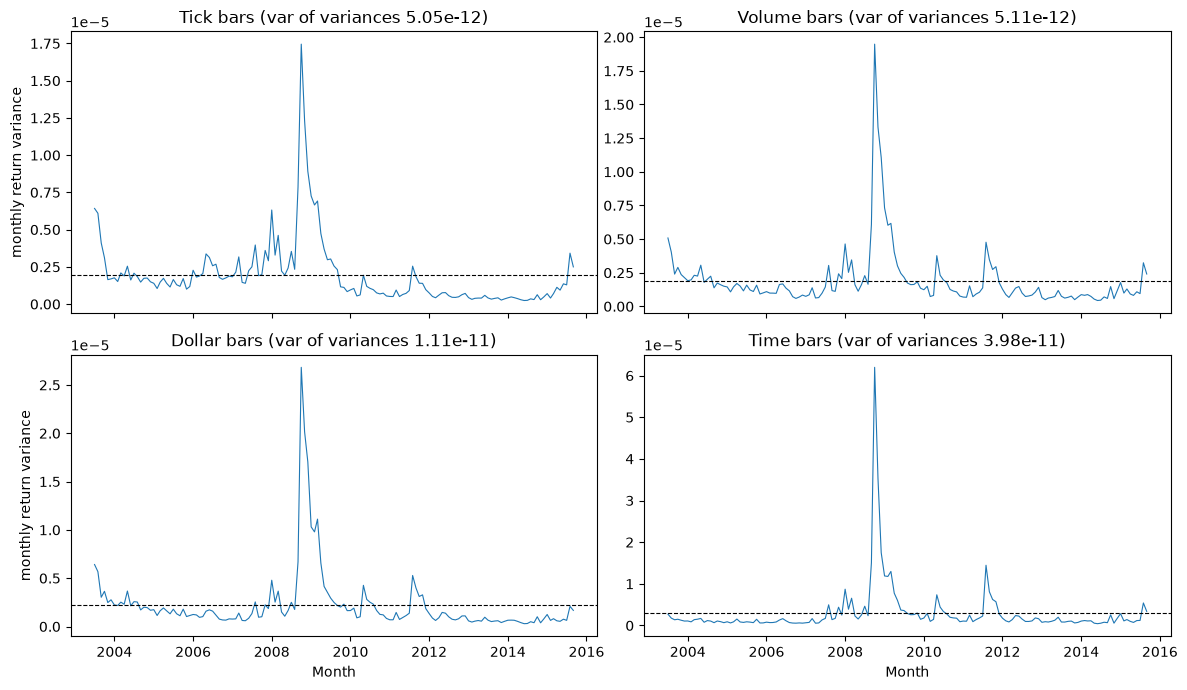

In [23]:
# Exercise 2.1 (d): variance of monthly return variances
# Uses `returns` from 2.1 (c): log returns over the window all bar types share. The last month
# is partial (data ends mid-October 2015), so it is dropped; the first month starts on 2003-07-01.
# Variance of variances = how much the per-month return variance moves around; smaller means
# the bar type gives more homoskedastic returns. Raw variances of different bar types sit on
# different scales (a bar type with larger bars has larger per-bar variance), so std / mean of
# the monthly variances is shown as a scale-free check on the ranking.
monthly_var = pd.DataFrame({name: r.groupby(r.index.to_period("M")).var()
                            for name, r in returns.items()}).iloc[:-1]

var_of_var = monthly_var.var()
summary_d = pd.DataFrame({"months": monthly_var.count(), "mean monthly var": monthly_var.mean(),
                          "var of variances": var_of_var,
                          "std / mean": monthly_var.std() / monthly_var.mean()})
print(f"{len(monthly_var)} months, {monthly_var.index.min()} -> {monthly_var.index.max()}")
print(summary_d.to_string(float_format=lambda x: f"{x:.4g}"))
print("smallest variance of variances among tick/volume/dollar:",
      var_of_var[["tick", "volume", "dollar"]].idxmin())
print("smallest std / mean among tick/volume/dollar:",
      summary_d.loc[["tick", "volume", "dollar"], "std / mean"].idxmin())

# One subplot per bar type; y-axes are not shared because per-bar variances differ in scale.
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, name in zip(axes.ravel(), BAR_TYPES):
    ax.plot(monthly_var.index.to_timestamp(), monthly_var[name], linewidth=0.8)
    ax.axhline(monthly_var[name].mean(), color="k", linestyle="--", linewidth=0.8)
    ax.set_title(f"{name.capitalize()} bars (var of variances {var_of_var[name]:.3g})")
for ax in axes[-1]:
    ax.set_xlabel("Month")
for ax in axes[:, 0]:
    ax.set_ylabel("monthly return variance")
fig.tight_layout()
plt.show()


### Exercise 2.1e

Answer to 2.1E: Volume achieves the lowest test statistic on the Jarque-Bera normality test on returns

        n_bars  skewness  excess kurtosis  JB statistic  p-value
tick    249422   0.01764            16.51     2.833e+06        0
volume  190298    0.1183            16.02     2.035e+06        0
dollar  190298   -0.1472            20.05     3.187e+06        0
time    146269    0.2736             55.4      1.87e+07        0
lowest JB statistic among tick/volume/dollar: volume


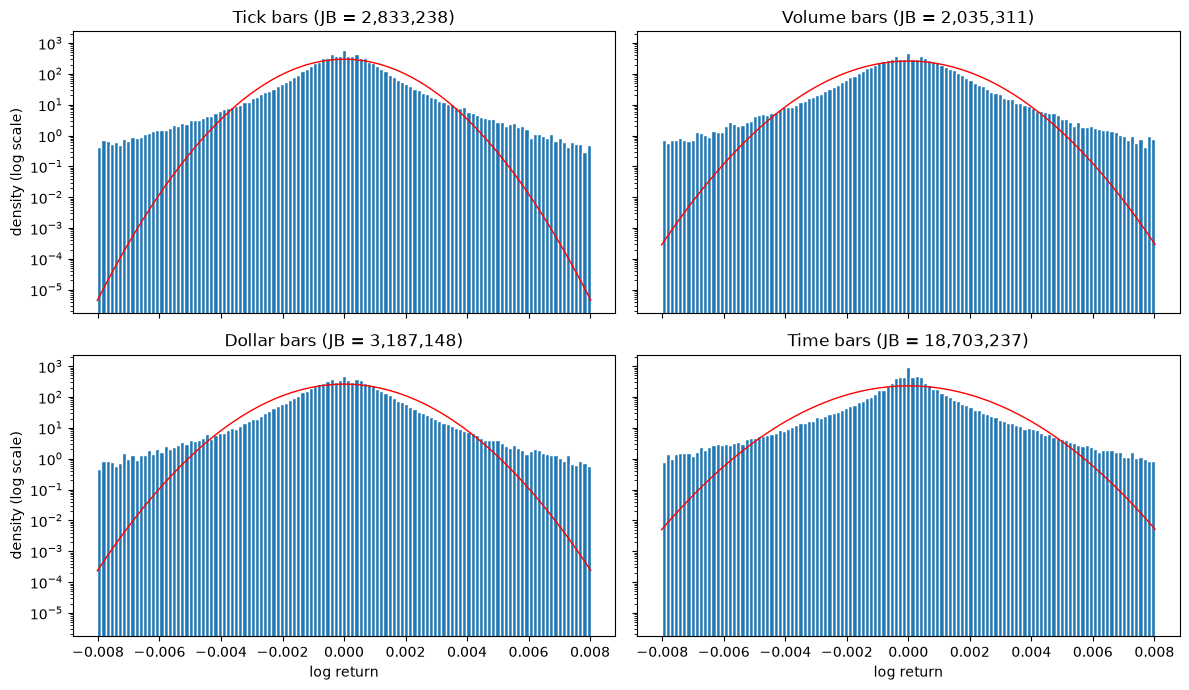

In [24]:
# Exercise 2.1 (e): Jarque-Bera normality test on bar returns
# Uses `returns` from 2.1 (c): log returns over the window all bar types share. JB combines
# sample skewness S and excess kurtosis K into JB = n/6 * (S^2 + K^2/4), ~ chi2(2) under
# normality. JB grows with n and every series has well over 100k bars, so every p-value is
# ~0 and the test is used only to RANK the bar types: a lower statistic = closer to normal.
from scipy.stats import jarque_bera

jb = {name: jarque_bera(r) for name, r in returns.items()}
summary_e = pd.DataFrame({"n_bars": n_bars,
                          "skewness": pd.Series({n: r.skew() for n, r in returns.items()}),
                          "excess kurtosis": pd.Series({n: r.kurt() for n, r in returns.items()}),
                          "JB statistic": pd.Series({n: t.statistic for n, t in jb.items()}),
                          "p-value": pd.Series({n: t.pvalue for n, t in jb.items()})})
print(summary_e.to_string(float_format=lambda x: f"{x:.4g}"))
print("lowest JB statistic among tick/volume/dollar:",
      summary_e.loc[["tick", "volume", "dollar"], "JB statistic"].idxmin())

# One subplot per bar type: return histogram (log y so the tails are visible) against the normal
# density with the same mean and std. Same x-range for all so the tail weight is comparable.
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
limit = 6 * min(r.std() for r in returns.values())
grid = np.linspace(-limit, limit, 400)
for ax, name in zip(axes.ravel(), BAR_TYPES):
    r = returns[name]
    ax.hist(r, bins=np.linspace(-limit, limit, 120), density=True, edgecolor="white")
    ax.plot(grid, np.exp(-0.5 * ((grid - r.mean()) / r.std()) ** 2) / (r.std() * np.sqrt(2 * np.pi)),
            color="r", linewidth=1)
    ax.set_yscale("log")
    ax.set_title(f"{name.capitalize()} bars (JB = {summary_e.loc[name, 'JB statistic']:,.0f})")
for ax in axes[-1]:
    ax.set_xlabel("log return")
for ax in axes[:, 0]:
    ax.set_ylabel("density (log scale)")
fig.tight_layout()
plt.show()


## Exercise 3.1

Form dollar bars for E-mini S&P 500 futures:

- (a) Apply a symmetric CUSUM filter (Chapter 2, Section 2.5.2.1) where the threshold is the standard deviation of daily returns (Snippet 3.1).
- (b) Use Snippet 3.4 on a pandas series t1, where numDays=1.
- (c) On those sampled features, apply the triple-barrier method, where ptSl=[1,1] and t1 is the series you created in point 1.b.
- (d) Apply getBins to generate the labels.

In [14]:
# Exercise 3.1


## Exercise 7.2

Take a pair of matrices (X, y), representing observed features and labels. These could be one of the datasets derived from the exercises in Chapter 3.

- (a) Derive the performance from a 10-fold CV of an RF classifier on (X, y), without shuffling.
- (b) Derive the performance from a 10-fold CV of an RF on (X, y), with shuffling.
- (c) Why are both results so different?
- (d) How does shuffling leak information?

In [15]:
# Exercise 7.2


## Exercise 13.2

Fit the time series of dollar bars of E-mini S&P 500 futures to an O-U process. Given those parameters:

- (a) Produce a heat-map of Sharpe ratios for various profit-taking and stop-loss levels.
- (b) What is the OTR?

In [16]:
# Exercise 13.2


## Exercise 14.2

On the dollar bars dataset for E-mini S&P 500 futures, compute

- (a) HHI index on positive returns.
- (b) HHI index on negative returns.
- (c) HHI index on time between bars.
- (d) The 95-percentile DD.
- (e) The 95-percentile TuW.
- (f) Annualized average return.
- (g) Average returns from hits (positive returns).
- (h) Average return from misses (negative returns).
- (i) Annualized SR.
- (j) Information ratio, where the benchmark is the risk-free rate.
- (k) PSR.
- (l) DSR, where we assume there were 100 trials, and the variance of the trials' SR was 0.5.

In [17]:
# Exercise 14.2
